In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from matplotlib.patches import Circle, RegularPolygon
from matplotlib.path import Path
from matplotlib.projections import register_projection
from matplotlib.projections.polar import PolarAxes
from matplotlib.spines import Spine
from matplotlib.transforms import Affine2D

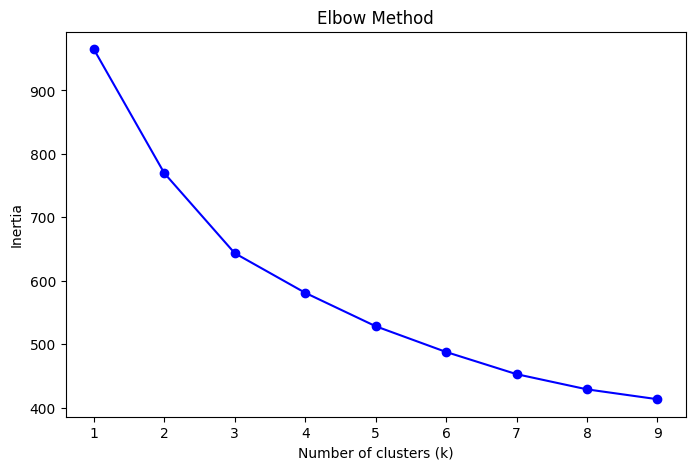

In [ ]:
encoded_df = pd.read_csv("../encoded_dataset.csv")

# features: leisure_hours, self_study_hours, sleep_hours, control_over_habit, focus_frequency
# exclude: delay_until_deadline (binary), timestamp, referrer, data_quality_check


np.random.seed(42)
features = encoded_df[
    [
        "delay_unenjoyable_assignments",
        "self_study_hours",
        "sleep_hours",
        "control_over_habit",
        "focus_frequency",
    ]
]

#  Scale
scaler = StandardScaler()
df_scaled = scaler.fit_transform(features)

#  Elbow graph to find optimal K
inertia = []
K = range(1, 10)
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df_scaled)
    inertia.append(kmeans.inertia_)

# test
# Plot the Elbow Method graph
plt.figure(figsize=(8, 5))
plt.plot(K, inertia, "bo-")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

K=2 Score: 0.1866
K=3 Score: 0.1980
K=4 Score: 0.1765
K=5 Score: 0.1783
K=6 Score: 0.1657
K=7 Score: 0.1706
K=8 Score: 0.1764


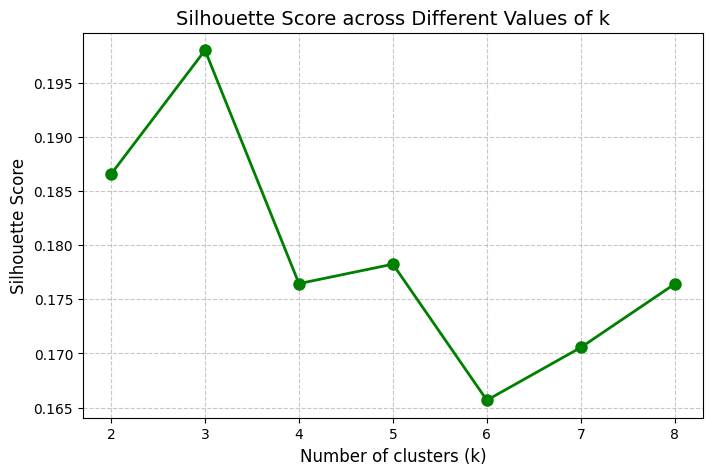

In [ ]:
sil_scores = []
K_range = range(2, 9)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    preds = km.fit_predict(df_scaled)
    score = silhouette_score(df_scaled, preds)
    sil_scores.append(score)
    print(f"K={k} Score: {score:.4f}")

# 6. Plot the Silhouette Score Graph
plt.figure(figsize=(8, 5))
plt.plot(K_range, sil_scores, "go-", linewidth=2, markersize=8)
plt.xlabel("Number of clusters (k)", fontsize=12)
plt.ylabel("Silhouette Score", fontsize=12)
plt.title("Silhouette Score across Different Values of k", fontsize=14)
plt.grid(True, linestyle="--", alpha=0.7)
plt.show()

Cluster
0    73
2    70
1    50
Name: count, dtype: int64


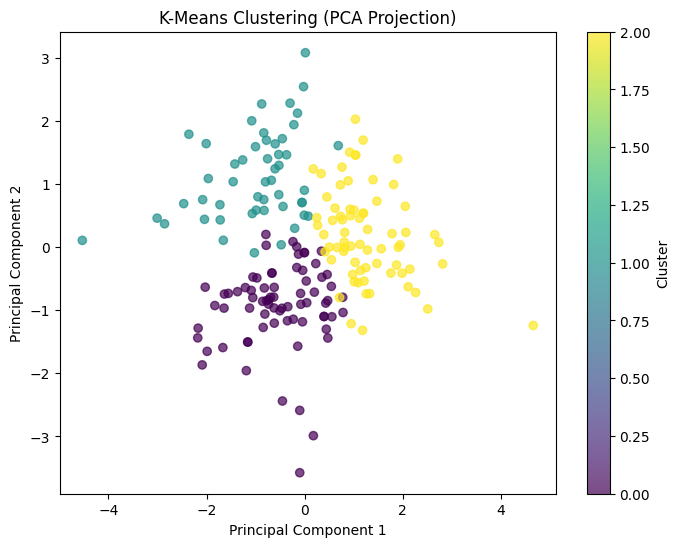

PCA Explained Variance: [0.31821889 0.23066002]


In [ ]:
# Apply K-Means Clustering
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(df_scaled)

# Add the cluster assignments back to the original dataset (FIXED VARIABLE NAME)
encoded_df["Cluster"] = clusters

print(encoded_df["Cluster"].value_counts())

# PCA for 2D Visualization
pca = PCA(n_components=2)
principal_components = pca.fit_transform(df_scaled)

# Plot the clusters
plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    principal_components[:, 0],
    principal_components[:, 1],
    c=clusters,
    cmap="viridis",
    alpha=0.7,
)
plt.colorbar(scatter, label="Cluster")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("K-Means Clustering (PCA Projection)")
plt.show()

print("PCA Explained Variance:", pca.explained_variance_ratio_)

PCA Loadings
                                    PC1       PC2
delay_unenjoyable_assignments  0.541895  0.087926
self_study_hours              -0.386790 -0.591072
sleep_hours                   -0.107663  0.755755
control_over_habit            -0.506993  0.214239
focus_frequency               -0.536759  0.160747


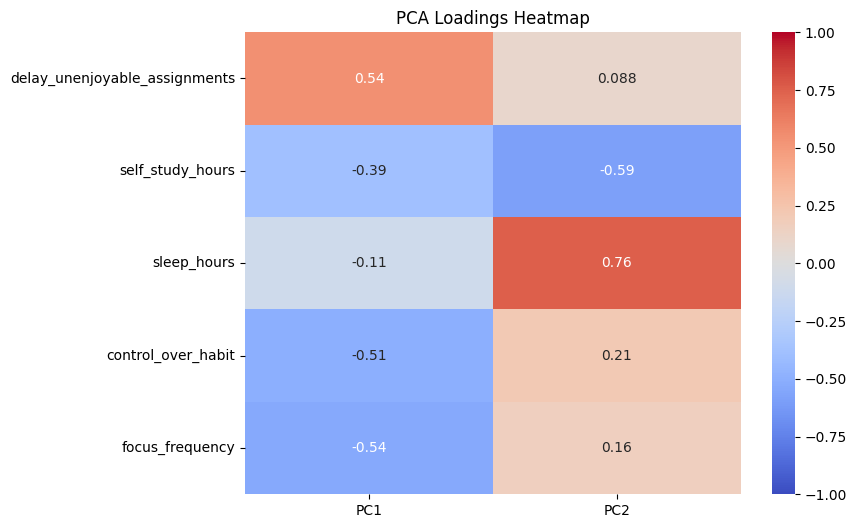

In [ ]:
loadings = pd.DataFrame(
    pca.components_.T,
    columns=["PC1", "PC2"],
    index=features.columns,  # Uses the 5 features selected earlier
)

print("PCA Loadings")
print(loadings)

# 2. Plot a Heatmap for easy visual interpretation
plt.figure(figsize=(8, 6))
sns.heatmap(loadings, annot=True, cmap="coolwarm", center=0, vmin=-1, vmax=1)
plt.title("PCA Loadings Heatmap")
plt.show()

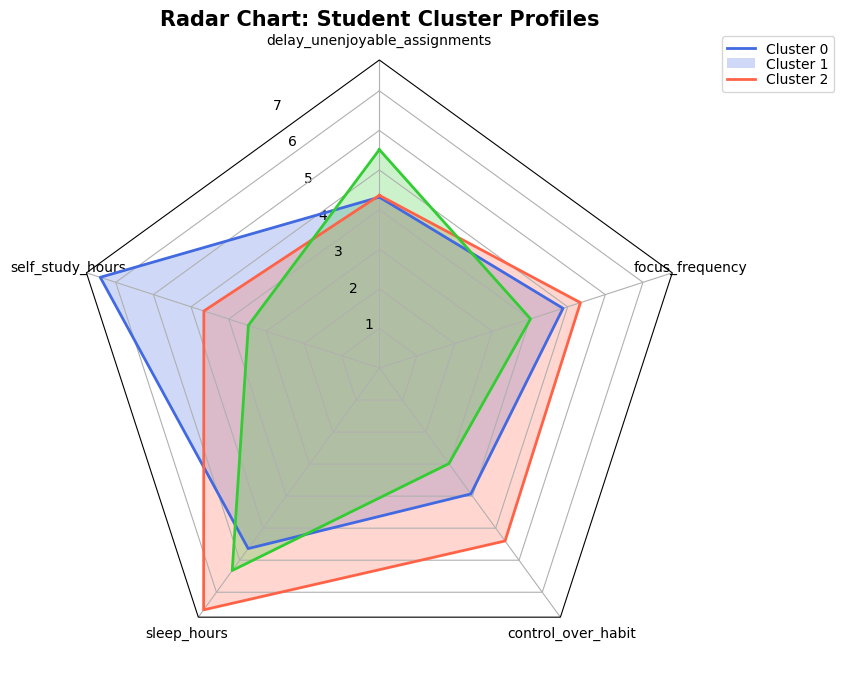

In [ ]:
from matplotlib.path import Path
from matplotlib.projections import PolarAxes


def radar_factory(num_vars, frame="circle"):
    """
    Create a radar chart with `num_vars` Axes.
    """
    # calculate evenly-spaced axis angles
    theta = np.linspace(0, 2 * np.pi, num_vars, endpoint=False)

    class RadarTransform(PolarAxes.PolarTransform):
        def transform_path_non_affine(self, path):
            if path._interpolation_steps > 1:
                path = path.interpolated(num_vars)
            return Path(self.transform(path.vertices), path.codes)

    class RadarAxes(PolarAxes):
        name = "radar"
        PolarTransform = RadarTransform

        def __init__(self, *args, **kwargs):
            super().__init__(*args, **kwargs)
            # rotate plot such that the first axis is at the top
            self.set_theta_zero_location("N")

        def fill(self, *args, closed=True, **kwargs):
            """Override fill so that line is closed by default"""
            return super().fill(closed=closed, *args, **kwargs)

        def plot(self, *args, **kwargs):
            """Override plot so that line is closed by default"""
            lines = super().plot(*args, **kwargs)
            for line in lines:
                self._close_line(line)

        def _close_line(self, line):
            x, y = line.get_data()
            if x[0] != x[-1]:
                x = np.append(x, x[0])
                y = np.append(y, y[0])
                line.set_data(x, y)

        def set_varlabels(self, labels):
            self.set_thetagrids(np.degrees(theta), labels)

        def _gen_axes_patch(self):
            if frame == "circle":
                return Circle((0.5, 0.5), 0.5)
            elif frame == "polygon":
                return RegularPolygon((0.5, 0.5), num_vars, radius=0.5, edgecolor="k")
            else:
                raise ValueError("Unknown value for 'frame': %s" % frame)

        def _gen_axes_spines(self):
            if frame == "circle":
                return super()._gen_axes_spines()
            elif frame == "polygon":
                spine = Spine(
                    axes=self,
                    spine_type="circle",
                    path=Path.unit_regular_polygon(num_vars),
                )
                spine.set_transform(
                    Affine2D().scale(0.5).translate(0.5, 0.5) + self.transAxes
                )
                return {"polar": spine}
            else:
                raise ValueError("Unknown value for 'frame': %s" % frame)

    register_projection(RadarAxes)
    return theta


encoded_df["Cluster"] = kmeans.fit_predict(df_scaled)
cluster_means = encoded_df.groupby("Cluster")[features.columns].mean()
# Prepare categories variables
categories = cluster_means.columns.tolist()
N = len(categories)

theta = radar_factory(N, frame="polygon")

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(projection="radar"))

# Define colors for clusters
colors = ["#4169E1", "#FF6347", "#32CD32", "#9370DB"]
labels = []

for i, row in cluster_means.iterrows():
    values = row.values
    color = colors[i % len(colors)]

    # Plot outline
    ax.plot(theta, values, color=color, linewidth=2)
    # Fill polygon
    ax.fill(theta, values, facecolor=color, alpha=0.25)

    labels.append(f"Cluster {i}")

ax.set_varlabels(categories)
ax.set_title(
    "Radar Chart: Student Cluster Profiles", weight="bold", size=15, position=(0.5, 1.1)
)

ax.legend(
    labels,
    loc="upper right",
    bbox_to_anchor=(1.25, 1.05),
    labelspacing=0.1,
    fontsize="medium",
)

plt.show()